In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap
import pandas as pd
import numpy as np

import sys
import os

/home/hootdarcy/ChE7700/che7700env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from models.unsupervised.dimReduction.dReduce import *

In [2]:
df1 = pd.read_csv('/home/hootdarcy/ChE7700/Stocks_Project/scripts/data/World-Stock-Prices-Dataset_ContData.csv')

dfint1 = df1.columns[0]
print(dfint1)
dfint1=df1.drop(columns=["Date"])
print(dfint1.sample(n=3))
dfint1 = dfint1.astype(float)

print(dfint1.columns)
print(dfint1.dtypes)

Date
               Open         High          Low        Close     Volume
1334    1020.630005  1020.630005  1008.609985  1014.940002    1853900
221263     4.136500     4.137500     3.894000     3.964000  192642000
130556    58.219235    58.327519    57.479317    57.497364    2927600
Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='str')
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object


In [3]:
df = pd.read_csv('/home/hootdarcy/ChE7700/Stocks_Project/scripts/data/World-Stock-Prices-Dataset_ContData.csv')



dfint = df.drop(columns=['Date'])
dfint = dfint.astype(float)
y = dfint.columns.to_numpy()



print(dfint.columns)
print(dfint.dtypes)
print(y)



Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='str')
Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object
['Open' 'High' 'Low' 'Close' 'Volume']


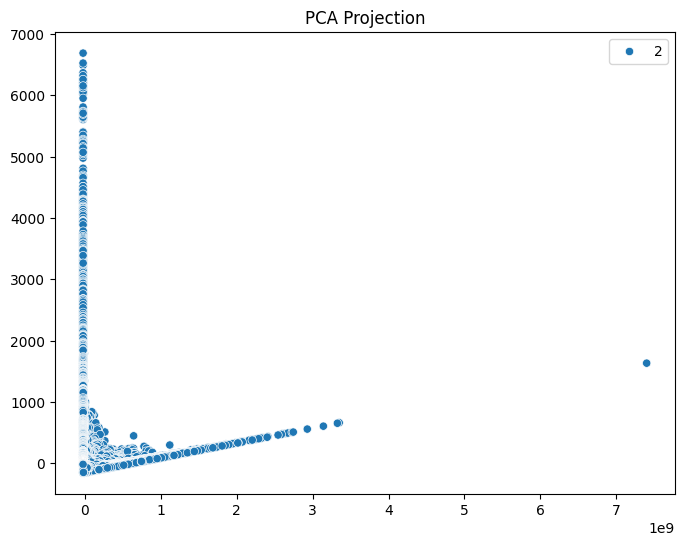

In [11]:
graphPCA(dfint, 2, 2)

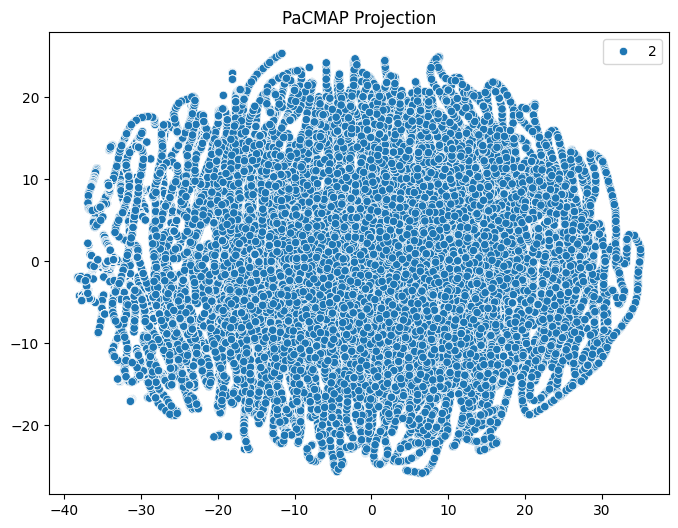

In [4]:
graphPaCMAP(dfint, 2)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

centers = 8
n_clusters = 8

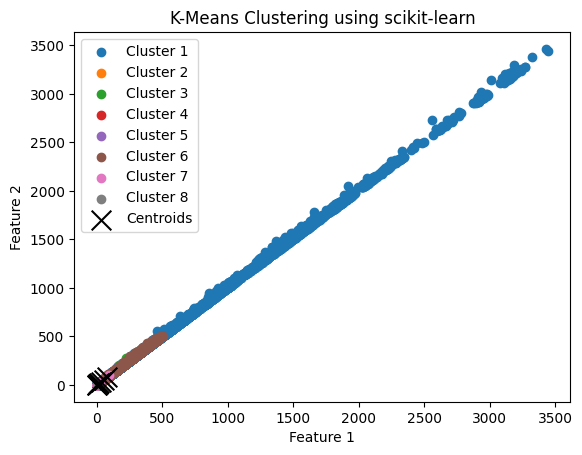

In [34]:
# Create and fit K-Means model
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(dfint1)

# Get results
labels = kmeans.labels_                 # Cluster assignment for each point
centroids = kmeans.cluster_centers_     # Final centroid positions

# Plot the clustering result
for i in range(centers):
    # Use .loc with the boolean mask and then select the desired columns
    cluster_data = dfint1.loc[labels == i]
    plt.scatter(cluster_data.iloc[:, 0], cluster_data.iloc[:, 1], label=f"Cluster {i+1}")

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='x', label="Centroids")

plt.title("K-Means Clustering using scikit-learn")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pacmap
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from matplotlib.patches import Circle

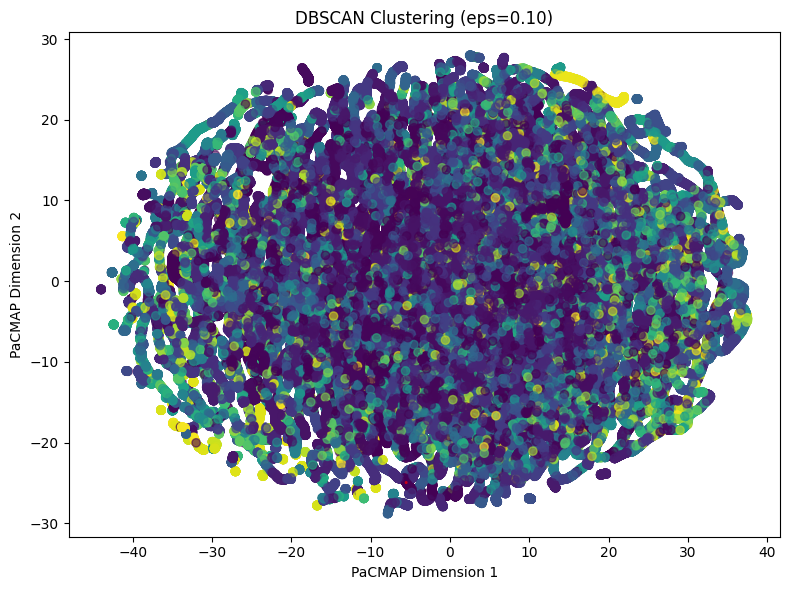

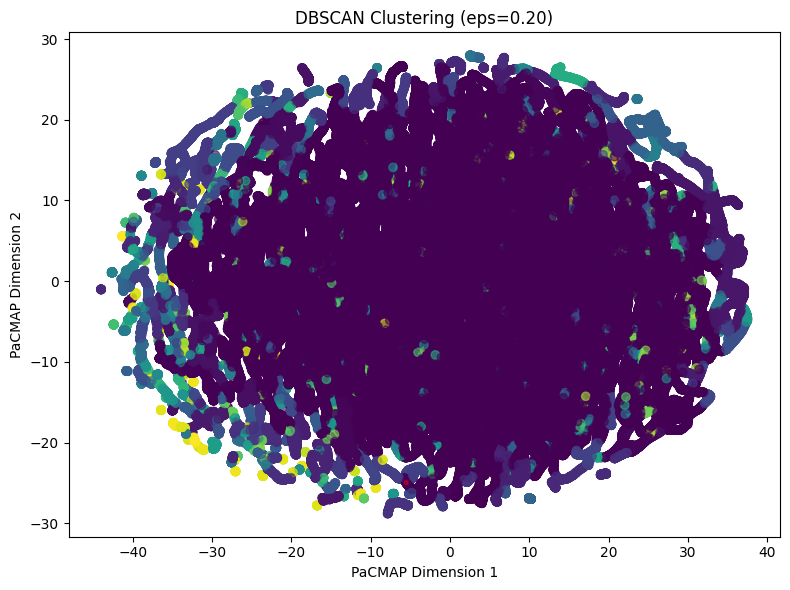

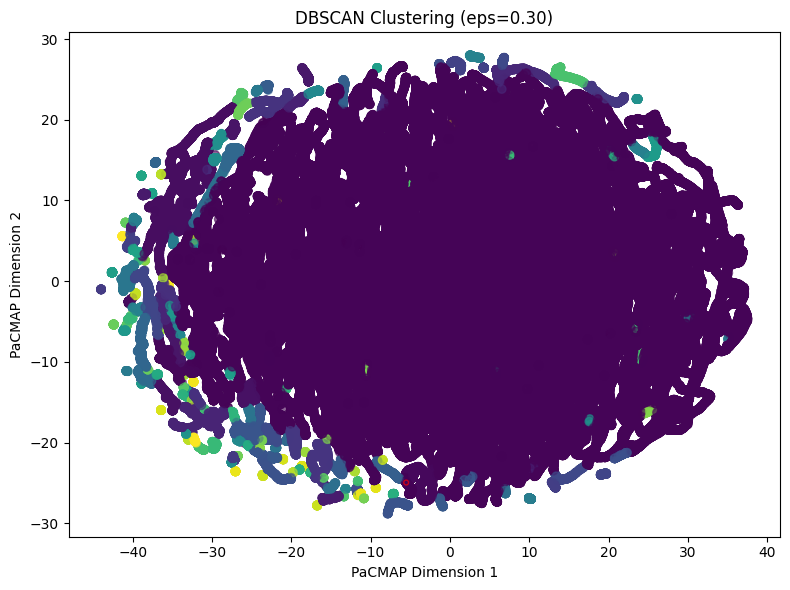

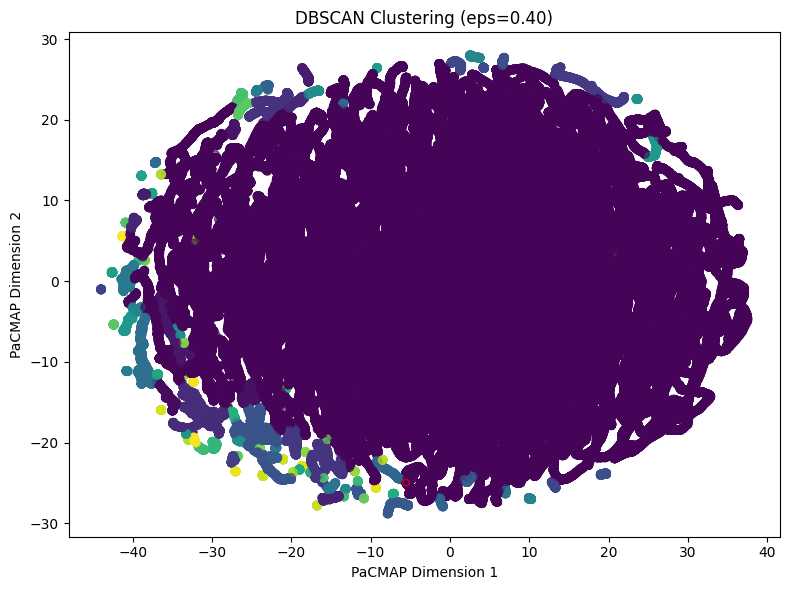

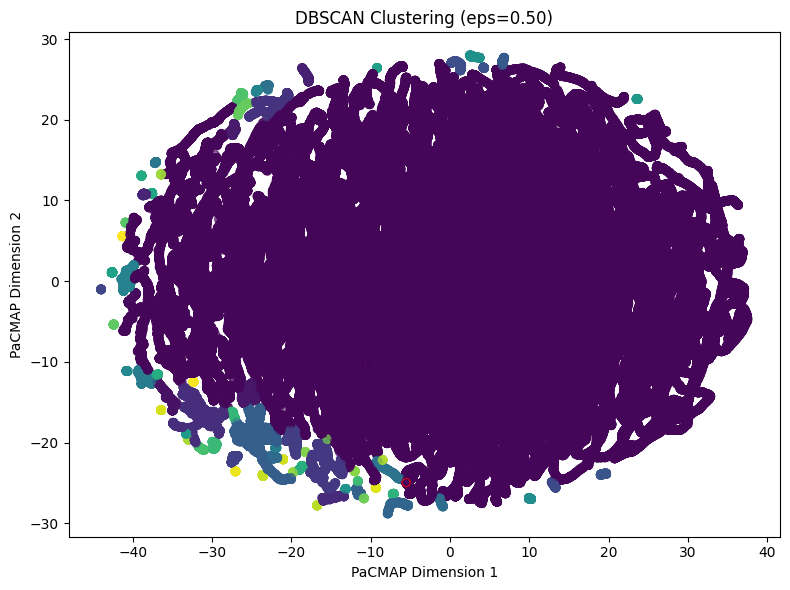

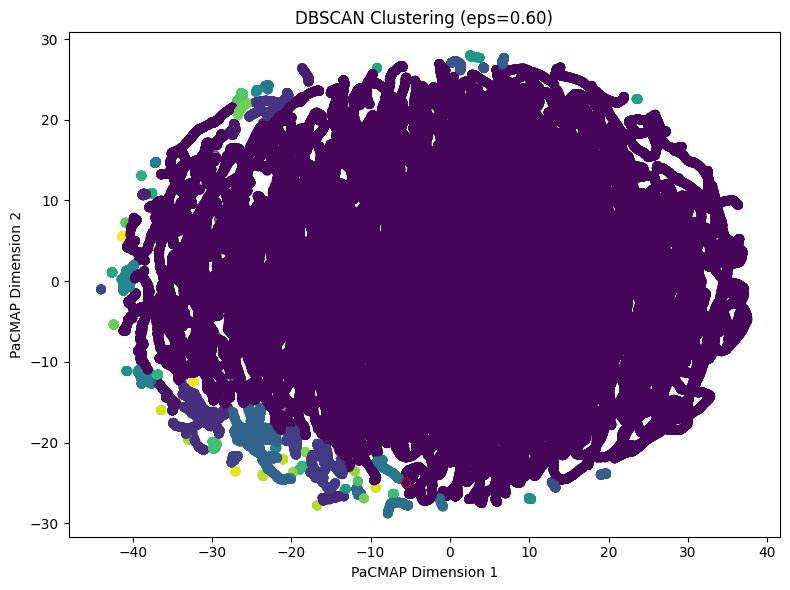

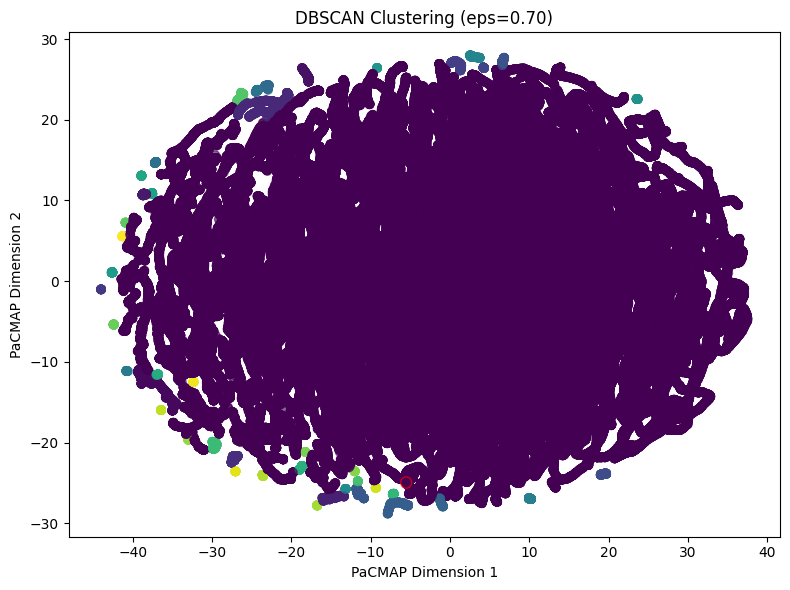

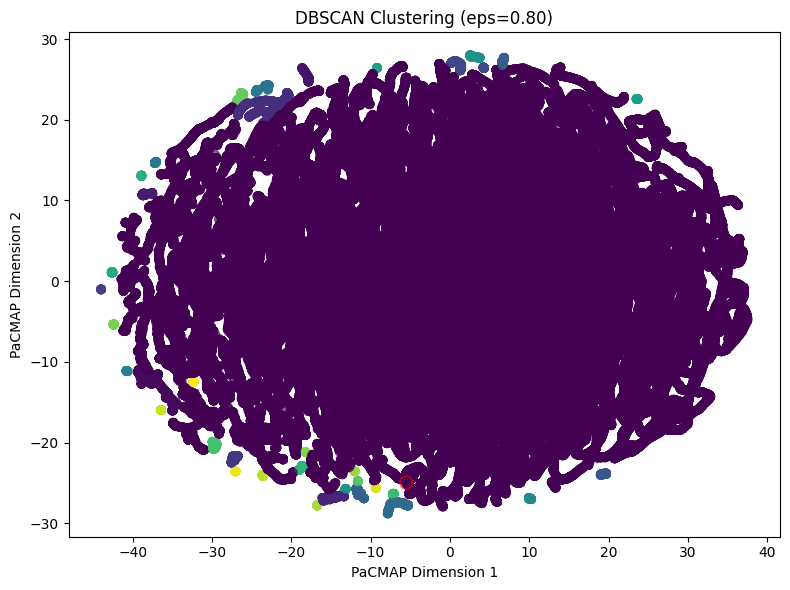

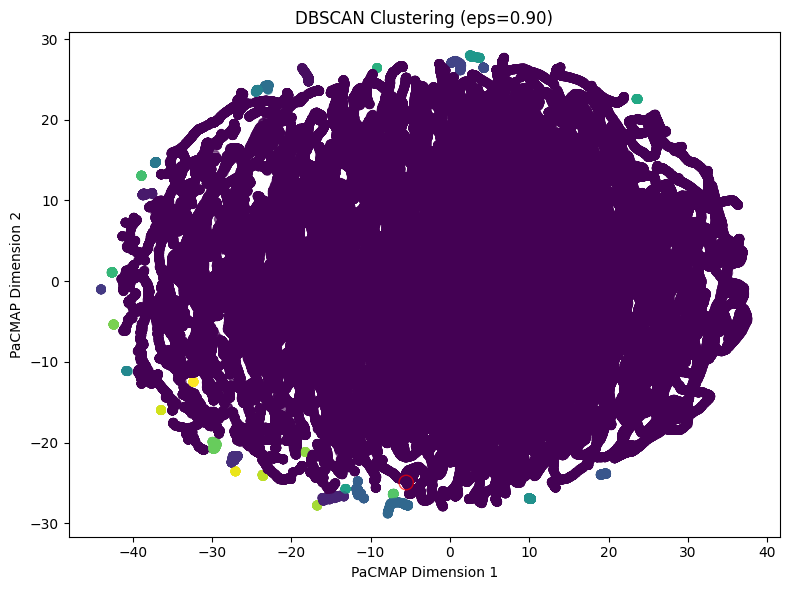

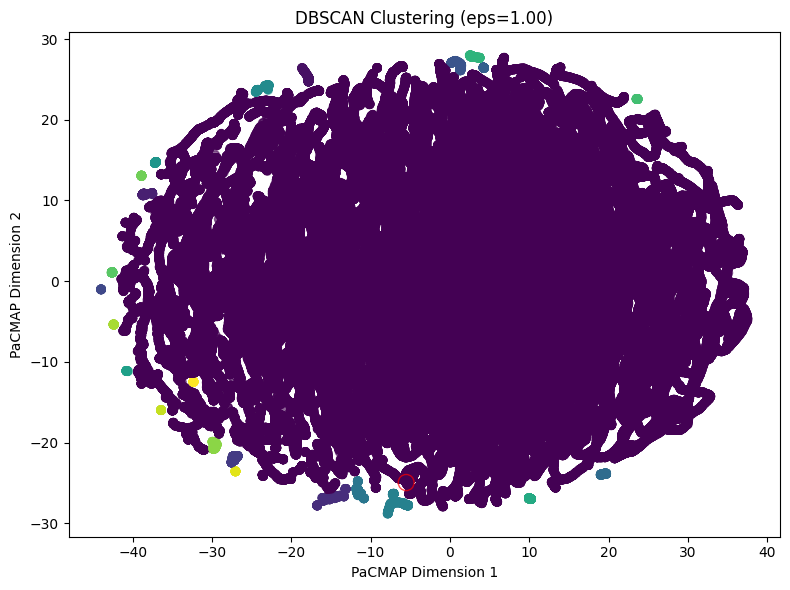

In [6]:
# Apply PaCMAP for dimensionality reduction
def apply_pacmap(data):
    reducer = pacmap.PaCMAP(n_components=2)
    return reducer.fit_transform(data)

# Plot at each iteration (no animation)
def plot_each_iteration(embedding, min_iter, max_iter, step):
    # Run DBSCAN once to pick a fixed core point (avoid noise)
    dbscan_init = DBSCAN(eps=min_iter, min_samples=5)
    labels_init = dbscan_init.fit_predict(embedding)

    core_indices = np.where(labels_init != -1)[0]
    if len(core_indices) > 0:
        fixed_index = core_indices[0]  # Choose the first core point
    else:
        fixed_index = np.random.randint(0, len(embedding))  # Fallback: pick any point if no core found

    fixed_point = embedding[fixed_index]

    for eps in np.arange(min_iter, max_iter + step, step):
        dbscan = DBSCAN(eps=eps, min_samples=5)
        labels = dbscan.fit_predict(embedding)

        plt.figure(figsize=(8, 6))
        plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="viridis", alpha=0.6)

        # Draw a single circle around the fixed core point
        circle = Circle((fixed_point[0], fixed_point[1]), eps, color="red", fill=False, alpha=0.7)
        plt.gca().add_patch(circle)

        plt.title(f"DBSCAN Clustering (eps={eps:.2f})")
        plt.xlabel("PaCMAP Dimension 1")
        plt.ylabel("PaCMAP Dimension 2")
        plt.tight_layout()
        plt.show()

#############################################################################################
# Main execution
data = StandardScaler().fit_transform(dfint1)  # Normalize data
embedding = apply_pacmap(dfint1)

# Define DBSCAN iteration range and interval
min_iter = 0.1  # Starting eps
max_iter = 1.0  # Ending eps
step = 0.1      # Step size

plot_each_iteration(embedding, min_iter, max_iter, step)
#############################################################################################
